# 01 · Exploring the IPL warehouse

**Purpose.** Understand the ball-by-ball data before modelling, and turn what we find into concrete
design decisions for the win-probability, score-projection and matchup models.

Every number here is read from the validated warehouse built by `criciq-data run`
(see [`docs/data-quality-report.md`](../docs/data-quality-report.md)). This notebook is exploration
only; production logic lives in the `pipelines/` and `ml/` packages.

**Questions**
1. How much data do we really have, in units that matter for modelling?
2. Is scoring stable across seasons, or has the game changed?
3. How do the powerplay, middle and death phases differ?
4. How much do the toss and chasing matter?
5. What are the base rates of each ball outcome?
6. Do venues differ enough to matter?
7. How much history does a typical batter–bowler matchup have?

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from criciq_core import paths
from criciq_core.phases import default_phase_config

con = duckdb.connect(str(paths.warehouse_path()), read_only=True)
q = lambda sql: con.sql(sql).df()  # noqa: E731

T20 = default_phase_config().for_format("T20")
PHASE_CASE = "CASE " + " ".join(
    f"WHEN over_no + 1 BETWEEN {p.first_over} AND {p.last_over} THEN '{p.label}'" for p in T20.phases
) + " END"

# Chart style: light surface, recessive grid, thin 2px lines, fixed categorical order
# (blue, orange, aqua), text in ink colours rather than series colours.
SERIES = ["#2a78d6", "#eb6834", "#1baf7a"]
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
plt.rcParams.update({
    "figure.figsize": (10, 4.2), "figure.dpi": 110, "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE, "axes.edgecolor": GRID, "axes.labelcolor": INK_2,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "lines.linewidth": 2,
    "legend.frameon": False, "axes.axisbelow": True, "legend.labelcolor": INK_2, "font.size": 10,
})
IMPACT_FROM = int(q("SELECT min(year) AS y FROM seasons WHERE impact_player_rule").y[0])

def impact_era(ax):
    ax.axvspan(IMPACT_FROM - 0.5, ax.get_xlim()[1], color=GRID, alpha=0.5, lw=0, zorder=0)
    ax.text(IMPACT_FROM - 0.35, ax.get_ylim()[0], " Impact Player era", va="bottom", color=INK_2, fontsize=9)

print("data version:", q("SELECT value FROM meta WHERE key = 'data_version'").value[0])

data version: 2026-05-31.713dafe9


## 1 · How much data do we have?

In [2]:
q("""
SELECT
    (SELECT count(*) FROM seasons)                                        AS seasons,
    (SELECT count(*) FROM matches)                                        AS matches,
    (SELECT count(*) FROM matches WHERE outcome_type = 'win')             AS decided_matches,
    (SELECT count(*) FROM deliveries)                                     AS deliveries,
    (SELECT count(*) FROM deliveries WHERE is_legal)                      AS legal_balls,
    (SELECT count(DISTINCT batter_id) FROM deliveries)                    AS batters,
    (SELECT count(DISTINCT bowler_id) FROM deliveries)                    AS bowlers
""")

,seasons,matches,decided_matches,deliveries,legal_balls,batters,bowlers
0,19,1243,1218,295732,284630,736,576


Close to 300,000 deliveries sounds like a lot, but **a win-probability model learns from match
outcomes, and there are only about 1,200 of them**. Deliveries within a match share one outcome, so
they are highly correlated.

**Decision:** keep win-probability models modest (monotonic gradient boosting plus a strong
logistic baseline), split train and test **by season** so no match straddles the split, and
report calibration rather than just accuracy.

## 2 · Has scoring changed over time?

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


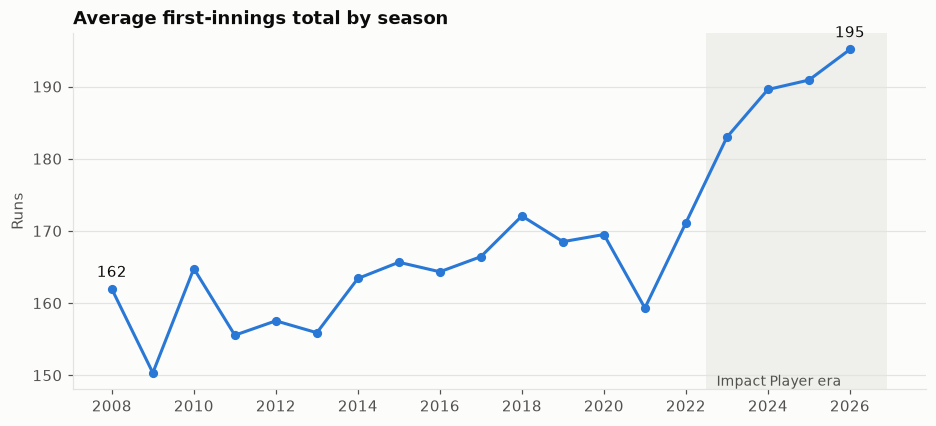

mean first-innings total before 2023: 163.1; since: 189.7 (+26.6)


In [3]:
first_innings = q("""
SELECT s.year, avg(i.runs) AS avg_score, count(*) AS n
FROM innings i JOIN matches m USING (match_id) JOIN seasons s USING (season_id)
WHERE i.innings_no = 1 AND NOT i.is_super_over
  AND m.outcome_type <> 'no_result' AND m.win_method IS NULL
GROUP BY s.year ORDER BY s.year
""")

fig, ax = plt.subplots()
ax.plot(first_innings.year, first_innings.avg_score, color=SERIES[0], marker="o", markersize=5)
ax.set_title("Average first-innings total by season")
ax.set_ylabel("Runs")
ax.set_xticks(first_innings.year[::2])
impact_era(ax)
for _, r in first_innings.iloc[[0, -1]].iterrows():
    ax.annotate(f"{r.avg_score:.0f}", (r.year, r.avg_score), textcoords="offset points",
                xytext=(0, 8), ha="center", color=INK)
plt.show()

early = first_innings.query("year < @IMPACT_FROM").avg_score.mean()
late = first_innings.query("year >= @IMPACT_FROM").avg_score.mean()
print(f"mean first-innings total before {IMPACT_FROM}: {early:.1f}; since: {late:.1f} (+{late - early:.1f})")

Scores were broadly stable at around 155–170 for fifteen seasons, then jumped by roughly 25 runs once
the Impact Player rule arrived (an extra specialist batter or bowler per side).

**Decision:** a model trained on 2008–2022 would systematically under-project modern totals. Every
model gets an **as-of league run-environment feature** (the rolling runs per ball of recent matches),
and the test set is always the most recent seasons, so this drift is measured rather than hidden.

## 3 · Scoring by phase

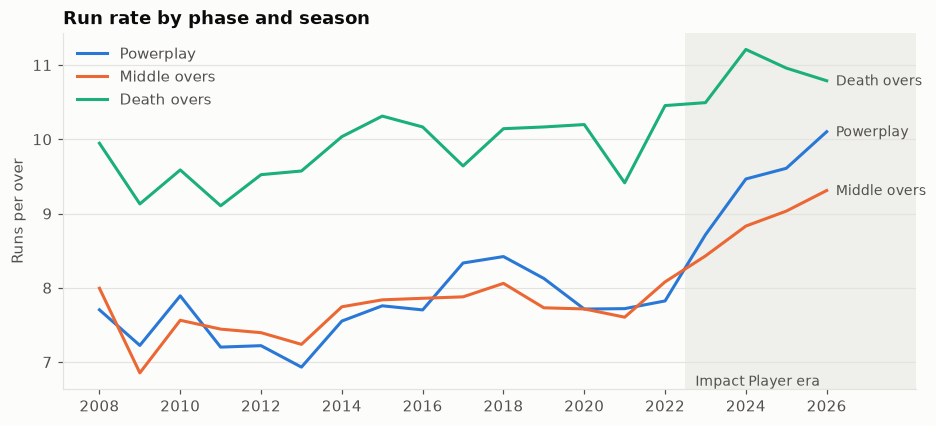

phase,Powerplay,Middle overs,Death overs
year,,,
2021,7.72,7.60,9.41
2022,7.82,8.08,10.45
2023,8.72,8.43,10.49
2024,9.47,8.83,11.21
2025,9.61,9.03,10.96
2026,10.10,9.31,10.79


In [4]:
phases = q(f"""
SELECT s.year, {PHASE_CASE} AS phase,
       6.0 * sum(d.runs_total) / count(*) FILTER (WHERE d.is_legal) AS run_rate,
       count(*) FILTER (WHERE d.is_legal) / nullif(sum(d.is_wicket::INT), 0) AS balls_per_wicket
FROM deliveries d JOIN innings i USING (match_id, innings_no)
JOIN matches m USING (match_id) JOIN seasons s USING (season_id)
WHERE NOT i.is_super_over
GROUP BY ALL ORDER BY s.year
""")
order = [p.label for p in T20.phases]

fig, ax = plt.subplots()
for color, label in zip(SERIES, order):
    part = phases[phases.phase == label]
    ax.plot(part.year, part.run_rate, color=color, label=label)
    last = part.iloc[-1]
    ax.annotate(label, (last.year, last.run_rate), textcoords="offset points", xytext=(6, -3),
                color=INK_2, fontsize=9)
ax.set_title("Run rate by phase and season")
ax.set_ylabel("Runs per over")
ax.set_xlim(right=phases.year.max() + 2.2)
ax.set_xticks(sorted(phases.year.unique())[::2])
impact_era(ax)
ax.legend(loc="upper left")
plt.show()

phases.pivot(index="year", columns="phase", values="run_rate")[order].round(2).tail(6)

Death overs are consistently the most expensive, and the recent rise touches every phase, the
powerplay most of all. The middle overs, once the quiet consolidation phase, now score at the rate
the death overs used to.

**Decision:** phase is a first-class feature everywhere, and phase boundaries come from
`config/phases.yaml` rather than being hard-coded. Player ratings are computed *per phase*,
because a strike rate of 150 means different things in the powerplay and at the death.

## 4 · The toss and chasing

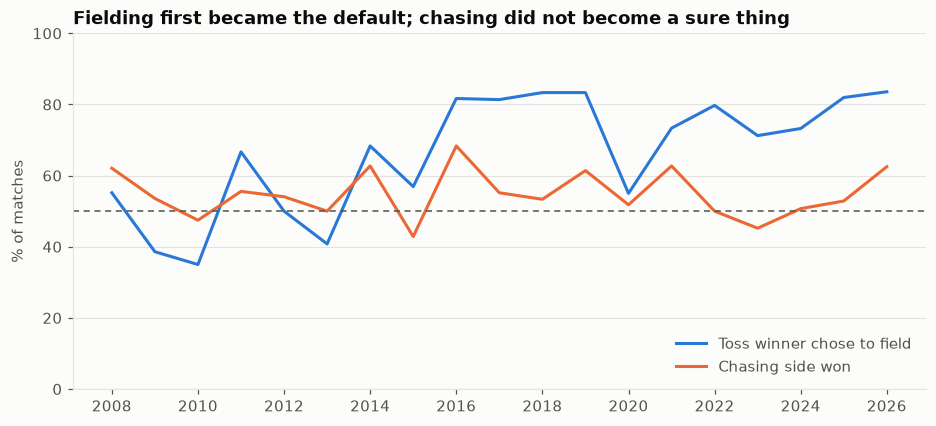

toss winners won 51.6% of decided matches


In [5]:
toss = q("""
SELECT s.year,
       avg((m.toss_decision = 'field')::INT) AS chose_to_field,
       avg((m.winner_id = i2.batting_team_id)::INT)
           FILTER (WHERE m.outcome_type = 'win') AS chasing_side_won,
       avg((m.winner_id = m.toss_winner_id)::INT)
           FILTER (WHERE m.outcome_type = 'win') AS toss_winner_won
FROM matches m JOIN seasons s USING (season_id)
JOIN innings i2 ON i2.match_id = m.match_id AND i2.innings_no = 2
GROUP BY s.year ORDER BY s.year
""")

fig, ax = plt.subplots()
for color, column, label in zip(SERIES, ["chose_to_field", "chasing_side_won"],
                                ["Toss winner chose to field", "Chasing side won"]):
    ax.plot(toss.year, 100 * toss[column], color=color, label=label)
ax.axhline(50, color=INK_2, lw=1, ls=(0, (4, 3)))
ax.set_title("Fielding first became the default; chasing did not become a sure thing")
ax.set_ylabel("% of matches")
ax.set_ylim(0, 100)
ax.set_xticks(toss.year[::2])
ax.legend(loc="lower right")
plt.show()

overall = q("""
SELECT avg((winner_id = toss_winner_id)::INT) AS toss_winner_won
FROM matches WHERE outcome_type = 'win'
""")
print(f"toss winners won {100 * overall.toss_winner_won[0]:.1f}% of decided matches")

Captains now choose to field first almost every time, yet chasing sides win only slightly more than
half the time, and winning the toss is close to a coin flip.

**Decision:** the toss enters the models as a weak context feature. It is not a headline
predictor, and the product should not imply it decides matches.

## 5 · What happens on a ball?

In [6]:
outcomes = q(f"""
WITH balls AS (
    SELECT {PHASE_CASE} AS phase,
           CASE
               WHEN d.is_wicket THEN 'Wicket'
               WHEN d.extras_wides > 0 OR d.extras_noballs > 0 THEN 'Wide / no-ball'
               WHEN d.is_six THEN 'Six'
               WHEN d.is_four THEN 'Four'
               WHEN d.runs_total = 0 THEN 'Dot'
               WHEN d.runs_total IN (1, 2, 3) THEN d.runs_total::VARCHAR || ' run' || CASE WHEN d.runs_total > 1 THEN 's' ELSE '' END
               ELSE 'Other'
           END AS outcome
    FROM deliveries d JOIN innings i USING (match_id, innings_no)
    JOIN matches m USING (match_id) JOIN seasons s USING (season_id)
    WHERE NOT i.is_super_over AND s.year >= {IMPACT_FROM}
)
SELECT phase, outcome, count(*) * 1.0 / sum(count(*)) OVER (PARTITION BY phase) AS share
FROM balls GROUP BY phase, outcome
""")
table = (outcomes.pivot(index="outcome", columns="phase", values="share")[order] * 100).round(1)
table.loc[["Dot", "1 run", "2 runs", "3 runs", "Four", "Six", "Wicket", "Wide / no-ball"]]

phase,Powerplay,Middle overs,Death overs
outcome,,,
Dot,36.2,23.6,19.2
1 run,26.9,45.2,37.1
2 runs,4.3,6.2,7.2
3 runs,0.3,0.1,0.2
Four,17.4,10.0,11.9
Six,6.4,6.6,9.9
Wicket,4.1,4.5,7.7
Wide / no-ball,4.1,3.7,6.7


Shares of deliveries by outcome in the Impact Player era, per phase (%). These are the base rates
the ball-outcome model has to beat, and the reason a naive "average" projection fails: the same ball
in the powerplay and at the death has a very different outcome distribution.

**Decision:** the ball-outcome model (which powers next-ball probabilities, leverage and the match
simulator) is a multiclass model over exactly these outcomes, with **phase-level marginals as its
baseline**. Wides and no-balls are modelled explicitly because they add runs *and* an extra ball.

## 6 · Do venues matter?

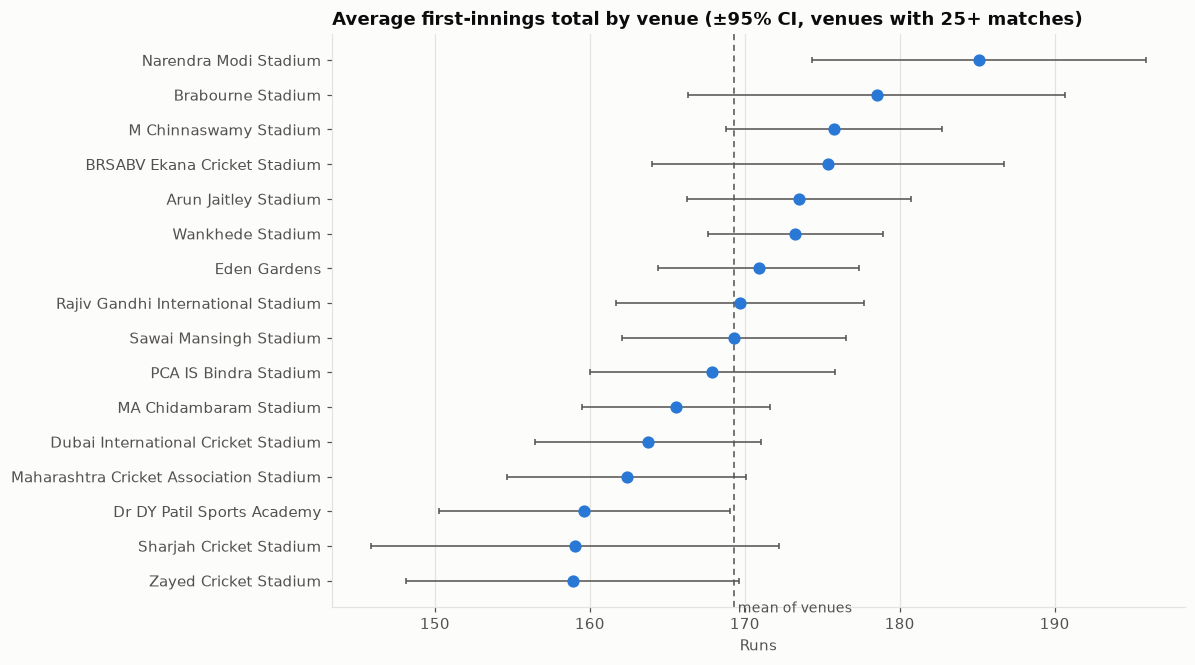

In [7]:
venues = q("""
SELECT v.name AS venue, count(*) AS matches, avg(i.runs) AS avg_score,
       1.96 * stddev_samp(i.runs) / sqrt(count(*)) AS ci95
FROM innings i JOIN matches m USING (match_id) JOIN venues v USING (venue_id)
WHERE i.innings_no = 1 AND NOT i.is_super_over AND m.outcome_type <> 'no_result'
  AND m.win_method IS NULL
GROUP BY v.name HAVING count(*) >= 25
ORDER BY avg_score
""")
league = venues.avg_score.mean()

# A dot plot, not bars: the axis does not start at zero, so length must not encode value.
fig, ax = plt.subplots(figsize=(10, 0.36 * len(venues) + 1))
ax.errorbar(venues.avg_score, venues.venue, xerr=venues.ci95, fmt="o", markersize=7,
            color=SERIES[0], ecolor=INK_2, elinewidth=1, capsize=2)
ax.axvline(league, color=INK_2, lw=1, ls=(0, (4, 3)))
ax.text(league, -0.6, " mean of venues", color=INK_2, fontsize=9, va="top")
ax.set_title("Average first-innings total by venue (±95% CI, venues with 25+ matches)")
ax.set_xlabel("Runs")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
plt.show()

Some grounds are clearly more batting-friendly than others, but the confidence intervals are wide,
and this chart pools all eras (venues used mostly in recent seasons look higher partly because of
the run inflation in section 2).

**Decision:** venue effects enter the models as **as-of, shrunk** run-environment features
(pulled toward the league average in proportion to how few matches a venue has hosted), never as a
raw venue identifier the model could overfit.

## 7 · How much history does a matchup have?

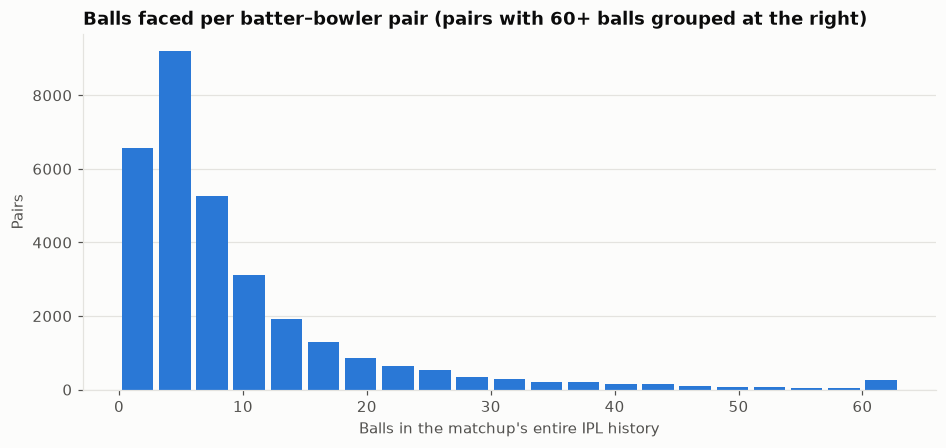

31,370 pairs · median 5 balls · 95% have fewer than 30 balls · 268 pairs have 60+ balls


In [8]:
pairs = q("""
SELECT batter_id, bowler_id, count(*) FILTER (WHERE extras_wides = 0) AS balls,
       sum(is_wicket::INT) AS dismissals
FROM deliveries GROUP BY ALL
""")

fig, ax = plt.subplots()
ax.hist(pairs.balls.clip(upper=61), bins=range(0, 64, 3), color=SERIES[0], rwidth=0.85)
ax.set_title("Balls faced per batter–bowler pair (pairs with 60+ balls grouped at the right)")
ax.set_xlabel("Balls in the matchup's entire IPL history")
ax.set_ylabel("Pairs")
plt.show()

share_small = (pairs.balls < 30).mean()
print(f"{len(pairs):,} pairs · median {pairs.balls.median():.0f} balls · "
      f"{100 * share_small:.0f}% have fewer than 30 balls · "
      f"{(pairs.balls >= 60).sum():,} pairs have 60+ balls")

The typical matchup has only a handful of balls of history. Reporting "dismissal probability"
from, say, 2 dismissals in 20 balls would be presenting noise as insight.

**Decision:** the Matchup Lab shows raw head-to-head numbers **with sample-size badges**, alongside
an **empirical-Bayes shrunk estimate** that borrows strength from similar batter/bowler types, and
a contextual ball-outcome model for next-ball probabilities.

## Summary: what the data tells the models

| Finding | Design decision |
|---|---|
| ~1,200 outcomes, not ~300k | Modest, monotonic models; season-based splits; calibration-first evaluation |
| Scores up ~25 runs in the Impact Player era | As-of league run-environment feature; most recent seasons held out for testing |
| Phases behave very differently | Phase as a core feature and per-phase player ratings, from configurable phase definitions |
| Toss is close to a coin flip | Weak context feature only |
| Outcome base rates differ by phase | Multiclass ball-outcome model with phase marginals as the baseline |
| Venue effects exist but are noisy | As-of, shrunk venue features instead of venue identifiers |
| Most matchups have tiny samples | Empirical-Bayes shrinkage and sample-size badges in the Matchup Lab |

In [9]:
con.close()